In [1]:
#Basic libraries
import pandas as pd
import  numpy as np
# visualization libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns
# Evaluation library
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep learning  libraries
import tensorflow as tf
import keras
from tensorflow.keras import layers
from keras.models import Sequential
from tensorflow.keras.layers import Input,Dense, Activation, Dropout
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

In [2]:
! pip install pydot

In [3]:
! pip install scikeras

In [4]:
# Digit mnist dataset
# Here we are splitting the data set to input and output training and testing data
# Here load_data() return the input and output data as a tuple so we are assigning it back to input and output tuple records

((X_train_digit,Y_train_digit), (X_test_digit, Y_test_digit))=mnist.load_data()

In [5]:
# Here each digit have its own matrix representation
X_train_digit

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [6]:
# Output digits for the training data
Y_train_digit

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

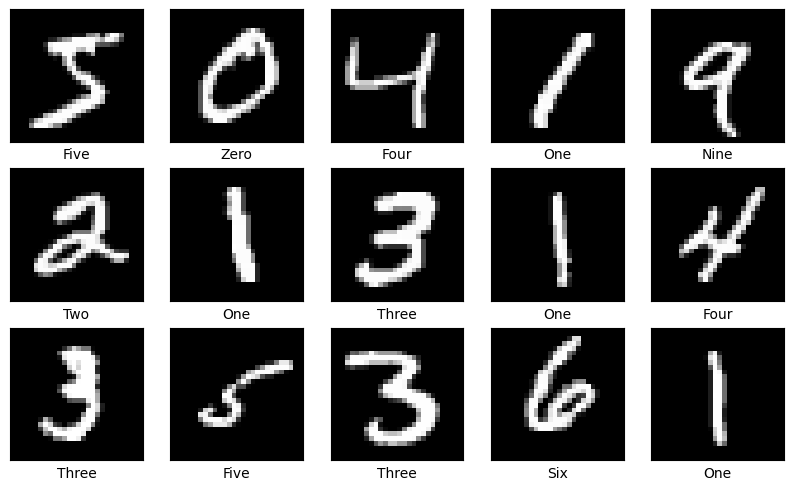

In [7]:
# Viewing the dataset
# Names & Numbers in the dataset 
col_names = ['Zero', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine']
# Giving names for the digitis from o to 9
# visualizing the digit
# Defining size of the figure(plot size) for displaying the digits
plt.figure(figsize=(10,10))
# We are trying to display 15 images here
for i in range(15):
    # 15 digits are partitioned in 3 rows by having 5 digits in a row
    # i+1 denotes the position of the digit
    plt.subplot(5,5,i+1)
    # removing the labels and ticks for x-axis
    plt.xticks([])
    # removing the labels and ticks for y-axis
    plt.yticks([])
    # To display 15 digits one by one from the input training set ( for example: X_train_digit[1] will display the first digit, which is 5 in our case)
    # color coding for the plot is given using cmap, here gray is used
    plt.imshow(X_train_digit[i], cmap='gray')
    # Printing the label using digits available in the output training set ( for example: col_names[Y_train_digit[1]] will display the label 'Five' from col_names
    plt.xlabel(col_names[Y_train_digit[i]])
plt.show()


## Input Preprocessing

In [8]:
# Checking the shape of the input digits
# we have 60000 digits in 28*28 shape, i.e 28 rows and 28 columns ( 3-dimensional)
X_train_digit.shape

(60000, 28, 28)

In [9]:
# ANN Model will work only if the input is two-dimensional, so we have to convert it from 3-D to 2-D
# Here we are flattening the digits into a single row (28*28=784)
X_train_digit = X_train_digit.reshape(60000, 784)
X_test_digit = X_test_digit.reshape(10000,784)

In [10]:
X_train_digit.shape

(60000, 784)

 ## Output Preprocessing

In [11]:
Y_test_digit
# shape is 1-D

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [12]:
Y_test_digit[2]

np.uint8(1)

In [13]:
# Encoding Digit MNIST Labels
# Here we are converting the single digit to 10 classes (0 to 9) using one hot encoding
# i.e if the digit is 1 then the particular digit will have value as 1 other all digits will have 0 for example [0,1,0,0,0,0,0,0,0,0]
Y_train_digit = to_categorical(Y_train_digit, num_classes=10)
Y_test_digit = to_categorical(Y_test_digit, num_classes=10)

In [14]:
print(Y_train_digit.shape)  # should be (60000, 10)
print(Y_test_digit.shape)

(60000, 10)
(10000, 10)


In [15]:
# Here we have digit 1 in the position 1
Y_train_digit[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [16]:
Y_train_digit[2] 
# digit 5 in position 2

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [17]:
# Creating base neural network
# Defining the layers to be used for the model

model = keras.Sequential([
    # dense layer contains 256 neurons and defining the activation function as 'relu' 
    # i.e hidden layer 1--> 784 neurons in the input layer will communicate to the 256 neurons in the hidden layer
    Input(shape=(784,)),
    layers.Dense(256, activation='relu'),
    #layers.Dropout(0.3)
    #Layers.BatchNormalization(),
    # output of the previous dense layer will interact with the below dense layer, i.e 256 neurons will communicate to the 64 neurons available in this layer
    layers.Dense(64, activation='relu'),
    #layers.Dropout(0.3)
    #layers.BatchNormalization(),
    # output of the previous dense layer will i.e based on the activation function of the 64 neurons, output digit is predicted as a result
    layers.Dense(10, activation='softmax'),
])


In [18]:
# Here we will get the summary of the params calculated in the model
# Here we have dense layer with 256 and input layer with 784 neuarons 
# 256 * (784+1) = 200960
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 218,058 (851.79 KB)

 Trainable params: 218,058 (851.79 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compiling the model
# Defining the metrics to calculate loss of the model
model.compile(loss="categorical_crossentropy", 
               optimizer='adam',
               metrics=['accuracy'])

In [20]:
#Fitting the model
# We are defining the epoch as 10, i.e one epoch is nothing one time it takes learn the entire dataset(feed forward and backward propogation) 
history=model.fit(X_train_digit, Y_train_digit, batch_size=100, epochs=10, validation_data=(X_test_digit,Y_test_digit))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6981 - loss: 6.2583 - val_accuracy: 0.8755 - val_loss: 0.4999
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8904 - loss: 0.4326 - val_accuracy: 0.9100 - val_loss: 0.3348
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9231 - loss: 0.3000 - val_accuracy: 0.9355 - val_loss: 0.3258
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9429 - loss: 0.2244 - val_accuracy: 0.9443 - val_loss: 0.2450
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9539 - loss: 0.1741 - val_accuracy: 0.9464 - val_loss: 0.2342
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9594 - loss: 0.1513 - val_accuracy: 0.9591 - val_loss: 0.1724
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9659 - loss: 0.1192 - val_accuracy: 0.9610 - val_loss: 0.1593
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9711 - loss: 0.1034 - val_accuracy: 0.

In [21]:
# Predicting the labels-DIGIT
y_predict = model.predict(X_test_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [22]:
y_predict[0]

array([1.6676908e-11, 6.2225571e-09, 6.8456785e-08, 8.6174180e-07,
       2.3632155e-11, 5.3749978e-12, 7.8278100e-24, 9.9999762e-01,
       4.2469774e-36, 1.4724799e-06], dtype=float32)

In [23]:
# Here we get maximum value of the encoded vector of y_predict
y_predicts=np.argmax(y_predict, axis=1)

In [24]:
y_predicts

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [25]:
# we are converting the actual output value in similar format, so that we can compare the predicted and actual output
y_test_digit_eval=np.argmax(Y_test_digit,axis=1)

In [26]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

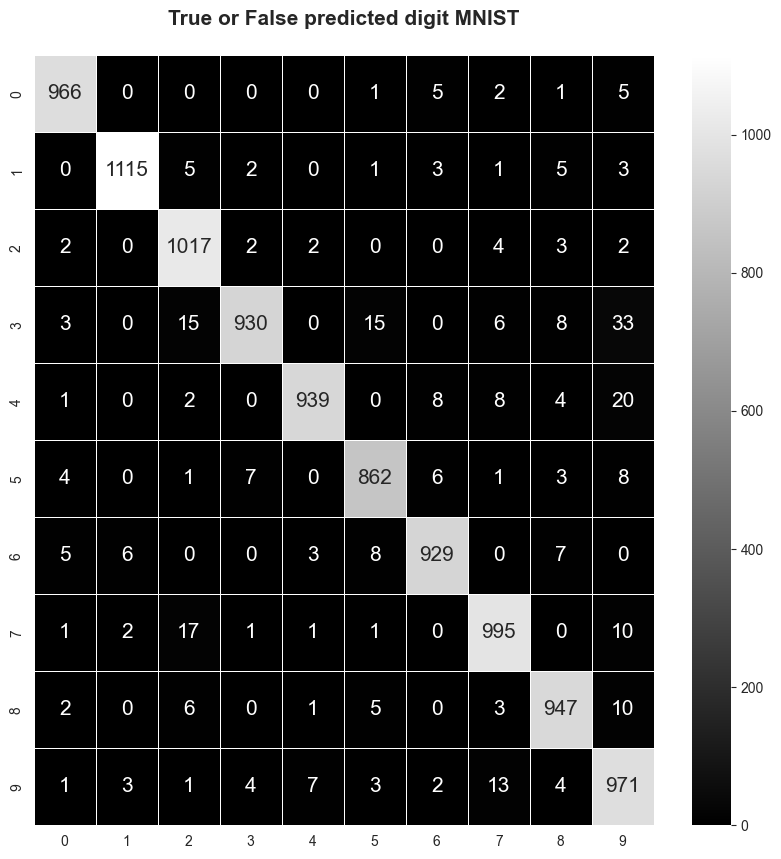

In [27]:
# Confusion matrix for Digit MNIST
# confusion matrix based on actual and predicted output values
con_mat=confusion_matrix(y_test_digit_eval, y_predicts)
#plt.style.use('seaborn-deep')
# Defining the style and palette for the display
sns.set_style("whitegrid")
sns.set_palette("deep")
# Mentioning the number of rows and columns 10*10(i.e 10 rows and 10 columns)
plt.figure(figsize=(10,10))
# We are using  heatmap using gray scale to display true or False predicted digit(i.e correctly or wrongly classified)
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidth=0.5,fmt="d",cmap="gray")
plt.title("True or False predicted digit MNIST\n", fontweight='bold',fontsize=15)
plt.show()

In [31]:
# Classification report
# Here we will be getting precision, recall, f1-score  for all the digits
from sklearn.metrics import classification_report
# Displaying classification report between actual and predicted output
print(classification_report(y_test_digit_eval, y_predicts))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.98      0.99      1135
           2       0.96      0.99      0.97      1032
           3       0.98      0.92      0.95      1010
           4       0.99      0.96      0.97       982
           5       0.96      0.97      0.96       892
           6       0.97      0.97      0.97       958
           7       0.96      0.97      0.97      1028
           8       0.96      0.97      0.97       974
           9       0.91      0.96      0.94      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [32]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


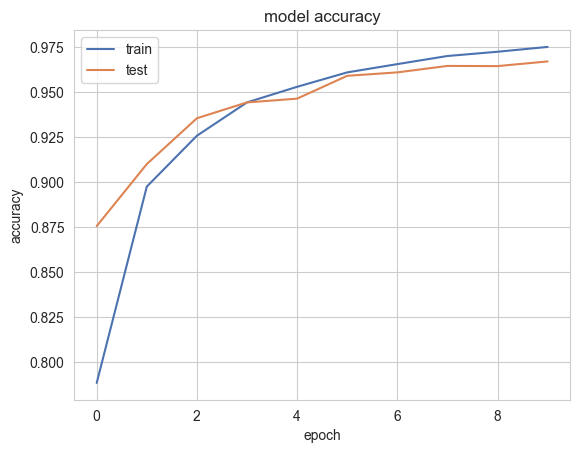

In [33]:
#summary history for accuracy
# To visualize how the model performed for testing and training data for each epoch
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='best')
plt.show()

In [41]:
#tf.expand_dims(X_test_digit[0])
# Verifying the model prediction by passing a single test data
# Here y_predict_single will have a array of values for all the 10 digits, but we need the maximum value from them to display the output digit
y_predict_single = model.predict(X_test_digit[[1]])
# We use np.argmax to find the maximum value from the array
y_predicts_single = np.argmax(y_predict_single, axis=1)
y_predicts_single

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([2])

Text(0.5, 0, 'Actual:Two, Pred:Two')

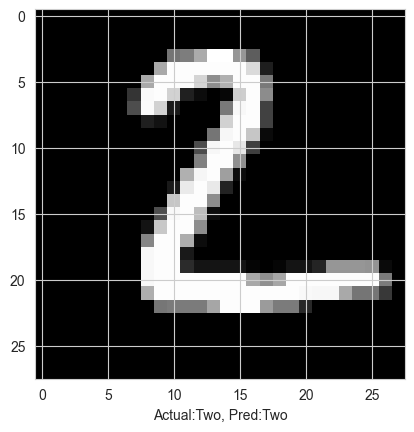

In [50]:
# Name and numbers in the dataset in order
col_names=['Zero', 'One','Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine']
# Visualizing the digits
# plt.figure(figsize=(10,10))
# displaying the digit available in position 1 in input test data
# reshaping it back to 28,28.. i.e how it was available before
plt.imshow(X_test_digit[1].reshape(28,28),cmap='gray')
# xlablel -> actual and predicted result
# we are displaying the label of the digit from col_names
# Actual digit value is displayed from output test data, here sample digit is 2. Applying argmax so the maximum value taken, and the respective label name from col_names will be displayed.
# Predicted digit value by the model
plt.xlabel("Actual:{}, Pred:{}".format(col_names[np.argmax(Y_test_digit[1])],col_names[y_predicts_single[0]]))